# Phase 2: 10-Class MNIST Classification — Logistic Regression (One-vs-Rest)
## Pipeline: Data Loading → Preprocessing → PCA → Training → CV Tuning → Learning Curves → Evaluation

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from sklearn.decomposition import PCA
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [2]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
LR_GRID = [0.001, 0.01, 0.05]
ITER_GRID = [300, 500, 1000]
DEFAULT_LR = 0.01
DEFAULT_ITER = 500

## 3. Data Loading & Preprocessing

In [3]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


## 4. Feature Extraction (Flatten → Scaler → PCA)

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} → {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 → 324 components (0.9503 var)


## 5. Utility Functions

In [5]:
def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def k_fold_split(X, y, k=5, seed=42):
    rng = np.random.RandomState(seed)
    idx = np.arange(len(y)); rng.shuffle(idx)
    fold_sz = len(y) // k
    folds = []
    for i in range(k):
        s, e = i*fold_sz, (i+1)*fold_sz if i < k-1 else len(y)
        v = idx[s:e]; t = np.concatenate([idx[:s], idx[e:]])
        folds.append((t, v))
    return folds

def cross_validate(model_cls, params, X, y, k=5):
    folds = k_fold_split(X, y, k=k)
    accs = []
    for fi, (ti, vi) in enumerate(folds):
        m = model_cls(**params); m.fit(X[ti], y[ti])
        acc = compute_accuracy(y[vi], m.predict(X[vi]))
        accs.append(acc)
        print(f"  Fold {fi+1}/{k}: {acc:.4f}")
    mean_acc = np.mean(accs)
    print(f"  Mean CV: {mean_acc:.4f}")
    return mean_acc

def plot_learning_curve(model_cls, params, X_tr, y_tr, X_vl, y_vl, fracs, title):
    tr_a, vl_a, szs = [], [], []
    n = len(y_tr)
    for f in fracs:
        sz = max(int(n*f), 10); szs.append(sz)
        idx = np.random.choice(n, sz, replace=False)
        m = model_cls(**params); m.fit(X_tr[idx], y_tr[idx])
        tr_a.append(compute_accuracy(y_tr[idx], m.predict(X_tr[idx])))
        vl_a.append(compute_accuracy(y_vl, m.predict(X_vl)))
    plt.figure(figsize=(8,5))
    plt.plot(szs, tr_a, 'o-', label='Train', color='#2ecc71')
    plt.plot(szs, vl_a, 's-', label='Val', color='#e74c3c')
    plt.fill_between(szs, tr_a, vl_a, alpha=0.15, color='gray')
    plt.xlabel('Training Size'); plt.ylabel('Accuracy')
    plt.title(title, fontweight='bold'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def evaluate_model(model, X_ts, y_ts, name):
    preds = model.predict(X_ts)
    acc = compute_accuracy(y_ts, preds)
    print(f"\n{'='*70}\n{name} — Test Acc: {acc:.4f} ({acc*100:.2f}%)\n{'='*70}")
    print(classification_report(y_ts, preds, target_names=[f'Digit {i}' for i in range(NUM_CLASSES)]))
    cm = confusion_matrix(y_ts, preds)
    plt.figure(figsize=(8,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.title(f'{name}\nTest Acc: {acc:.4f}', fontweight='bold')
    plt.tight_layout(); plt.show()
    return acc

## 6. Logistic Regression Model (One-vs-Rest)

Uses **sigmoid** activation and **binary cross-entropy loss** per class.

In [6]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.models = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        self.models = []
        for c in self.classes_:
            yb = (y == c).astype(float)
            w, b = np.zeros(d), 0.0
            for _ in range(self.n_iter):
                yh = self._sigmoid(X @ w + b)
                w -= self.lr * (X.T @ (yh - yb)) / n
                b -= self.lr * np.sum(yh - yb) / n
            self.models.append((w, b))
        return self

    def predict(self, X):
        scores = np.column_stack([self._sigmoid(X @ w + b) for w, b in self.models])
        return self.classes_[np.argmax(scores, axis=1)]

## 7. Baseline Training

BASELINE LOGISTIC REGRESSION

LR Baseline — Test Acc: 0.8474 (84.74%)
                 precision     recall   f1-score    support

        Digit 0       0.86       0.96       0.91        947
        Digit 1       0.78       0.96       0.86        947
        Digit 2       0.88       0.79       0.83        947
        Digit 3       0.83       0.83       0.83        947
        Digit 4       0.86       0.90       0.88        947
        Digit 5       0.87       0.77       0.81        947
        Digit 6       0.87       0.92       0.89        947
        Digit 7       0.83       0.86       0.84        947
        Digit 8       0.85       0.73       0.79        947
        Digit 9       0.87       0.76       0.81        947

       accuracy                             0.85       9470
      macro avg       0.85       0.85       0.85       9470
   weighted avg       0.85       0.85       0.85       9470



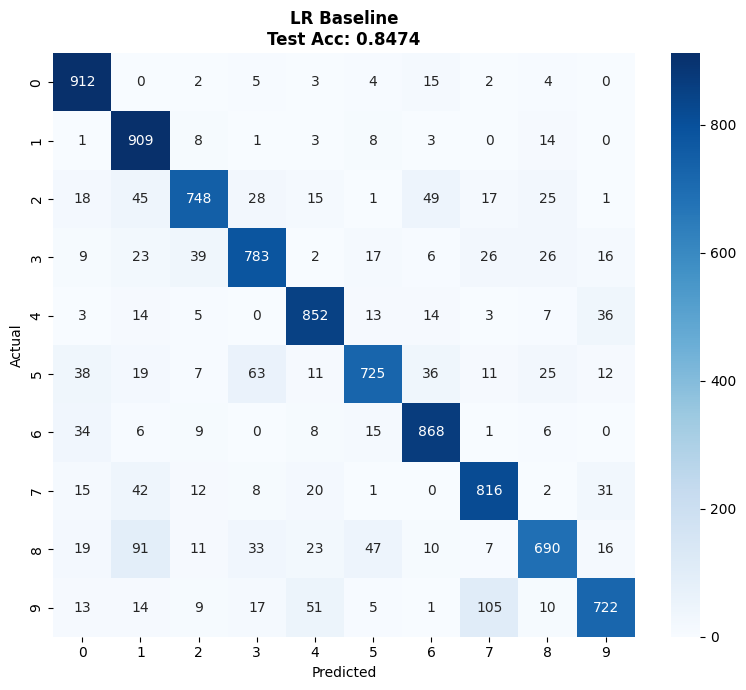

In [7]:
print("BASELINE LOGISTIC REGRESSION")
lr_base = LogisticRegression(learning_rate=DEFAULT_LR, n_iterations=DEFAULT_ITER)
lr_base.fit(X_train_pca, y_train)
base_acc = evaluate_model(lr_base, X_test_pca, y_test, "LR Baseline")

## 8. Hyperparameter Tuning (K-Fold CV)

In [8]:
best_acc, best_p = 0, {}
for lr in LR_GRID:
    for it in ITER_GRID:
        p = {'learning_rate': lr, 'n_iterations': it}
        print(f"\nLR={lr}, Iter={it}")
        a = cross_validate(LogisticRegression, p, X_train_pca, y_train, k=K_FOLDS)
        if a > best_acc: best_acc, best_p = a, p.copy()
print(f"\nBest: {best_p} (CV={best_acc:.4f})")


LR=0.001, Iter=300
  Fold 1/5: 0.8032
  Fold 2/5: 0.8093
  Fold 3/5: 0.8041
  Fold 4/5: 0.8052
  Fold 5/5: 0.8040
  Mean CV: 0.8052

LR=0.001, Iter=500
  Fold 1/5: 0.8167
  Fold 2/5: 0.8204
  Fold 3/5: 0.8170
  Fold 4/5: 0.8205
  Fold 5/5: 0.8151
  Mean CV: 0.8180

LR=0.001, Iter=1000
  Fold 1/5: 0.8301
  Fold 2/5: 0.8349
  Fold 3/5: 0.8306
  Fold 4/5: 0.8327
  Fold 5/5: 0.8284
  Mean CV: 0.8313

LR=0.01, Iter=300
  Fold 1/5: 0.8474
  Fold 2/5: 0.8499
  Fold 3/5: 0.8470
  Fold 4/5: 0.8474
  Fold 5/5: 0.8411
  Mean CV: 0.8465

LR=0.01, Iter=500
  Fold 1/5: 0.8549
  Fold 2/5: 0.8585
  Fold 3/5: 0.8549
  Fold 4/5: 0.8556
  Fold 5/5: 0.8475
  Mean CV: 0.8543

LR=0.01, Iter=1000
  Fold 1/5: 0.8671
  Fold 2/5: 0.8706
  Fold 3/5: 0.8659
  Fold 4/5: 0.8681
  Fold 5/5: 0.8585
  Mean CV: 0.8660

LR=0.05, Iter=300
  Fold 1/5: 0.8742
  Fold 2/5: 0.8763
  Fold 3/5: 0.8750
  Fold 4/5: 0.8746
  Fold 5/5: 0.8660
  Mean CV: 0.8732

LR=0.05, Iter=500
  Fold 1/5: 0.8828
  Fold 2/5: 0.8838
  Fold 3/5: 0.


LR Tuned — Test Acc: 0.8900 (89.00%)
                 precision     recall   f1-score    support

        Digit 0       0.93       0.97       0.95        947
        Digit 1       0.86       0.95       0.90        947
        Digit 2       0.90       0.86       0.88        947
        Digit 3       0.88       0.85       0.86        947
        Digit 4       0.88       0.92       0.90        947
        Digit 5       0.88       0.87       0.87        947
        Digit 6       0.91       0.93       0.92        947
        Digit 7       0.90       0.89       0.89        947
        Digit 8       0.88       0.82       0.85        947
        Digit 9       0.89       0.85       0.87        947

       accuracy                             0.89       9470
      macro avg       0.89       0.89       0.89       9470
   weighted avg       0.89       0.89       0.89       9470



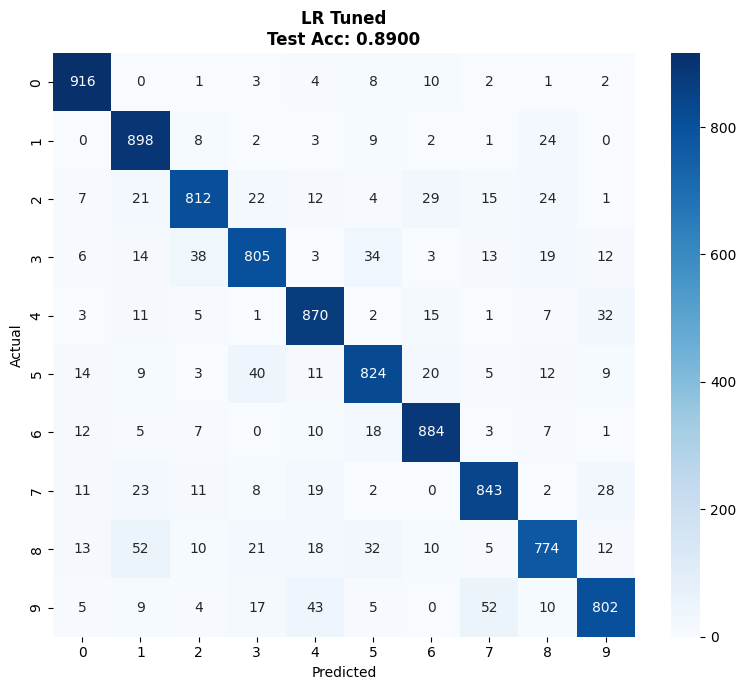

In [9]:
lr_tuned = LogisticRegression(**best_p)
lr_tuned.fit(X_train_pca, y_train)
tuned_acc = evaluate_model(lr_tuned, X_test_pca, y_test, "LR Tuned")

## 9. Learning Curve

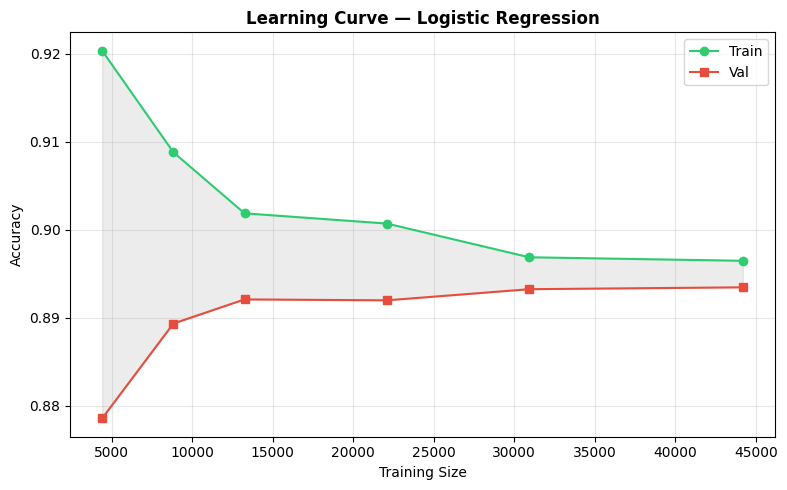

In [10]:
plot_learning_curve(LogisticRegression, best_p, X_train_pca, y_train,
                    X_val_pca, y_val, LC_FRACTIONS, "Learning Curve — Logistic Regression")

## 10. Summary
| Config | Test Accuracy |
|--------|-------------|
| Baseline | See above |
| Tuned (CV) | See above |

**Analysis**: If train & val curves converge at moderate accuracy → high bias (underfitting).
The linear OvR model may struggle with complex 10-class boundaries.